# Modelo Bayesiano Hierárquico da Frequência de Sinistros de Seguros por Região

## Resumo Executivo

Uma seguradora de ramos elementares precisa da frequência esperada de sinistros de automóvel para cada território de tarifação, mas alguns territórios têm pouca exposição, de modo que suas taxas brutas reagem de forma exagerada a um punhado de sinistros. Usando o **PROC MCMC**, ajustamos uma regressão de Poisson hierárquica com um offset de exposição, uma covariável de franquia no nível da apólice, e interceptos aleatórios por região extraídos de uma hiperdistribuição comum. O ajuste recupera uma média posterior de log-frequência basal de **0.43** (`beta0`), uma inclinação negativa da franquia (`beta_ded` com média posterior **-0.13**, intervalo de credibilidade de 95% aproximadamente **[-0.32, 0.10]**), e um desvio-padrão entre regiões de cerca de **0.48** (a partir de `tau2`). O agrupamento parcial (partial pooling) puxa as estimativas mais ruidosas das regiões pequenas em direção ao centro da carteira: a região 5, de pouca exposição e taxa alta (frequência bruta 3.41), se estabiliza em uma relatividade posterior de **1.43**, enquanto a região 4, de pouca exposição e taxa baixa (frequência bruta 0.45), se estabiliza em **0.49** — cada uma com bandas de credibilidade largas que sinalizam seus dados limitados. A posterior completa transforma a relatividade de cada região em um intervalo de credibilidade utilizável para decisões de precificação e capital.

## Fontes de Dados

Todos os dados são gerados sinteticamente dentro do notebook (sem arquivos externos). Uma única etapa DATA simula uma carteira de apólices-ano em 6 regiões.

| Conjunto de Dados | Linhas | Variável | Descrição |
|---------|------|----------|-------------|
| `claims` | 96 apólices-ano | `region` | Id da região 1-6 (território de tarifação) |
| | | `exposure` | Exposição ganha em apólices-ano (0.3-1.0) |
| | | `deductible` | Franquia padronizada da apólice (centrada) |
| | | `region_eff` | Efeito latente verdadeiro de log-frequência da região (referência) |
| | | `nclaims` | Contagem de sinistros observada ~ Poisson(exposure x exp(eta)) |

O processo gerador de dados verdadeiro é `log(rate) = beta0 + beta_ded * deductible + u_region`, com interceptos de região `u_region` variando de **-0.45 a +0.40** e um offset de `exposure`, de modo que a posterior recuperada possa ser comparada com a verdade semeada. Os tamanhos das regiões são deliberadamente desiguais (24, 20, 16, 14, 12, 10 apólices-ano) para que os territórios pequenos exibam as taxas brutas ruidosas que o agrupamento parcial foi projetado para estabilizar.

> **Nota sobre o tamanho da amostra.** Este ambiente é executado sem licença, o que limita cada conjunto de dados a 100 observações. A carteira, portanto, é dimensionada em 96 apólices-ano em 6 regiões — pequena o suficiente para sobreviver ao limite, mantendo ainda assim um intercepto aleatório próprio para cada região. Os resumos posteriores impressos pelo PROC MCMC usam a cadeia completa de 6.000 amostras salvas; qualquer etapa *posterior* que releia o conjunto de dados `OUTPOST=` (os intervalos de credibilidade por região e os gráficos de traço/densidade abaixo) vê apenas as primeiras 100 amostras salvas, novamente por causa do limite. Esses resumos posteriores são um recorte inicial honesto da cadeia, não a posterior completa, e são rotulados como tal.

# Frequência Bayesiana Hierárquica de Sinistros por Região

Uma seguradora de ramos elementares precisa da **frequência esperada de sinistros por região** para definir relatividades de território de tarifação. O desafio: regiões pequenas/rurais têm pouca exposição, de modo que suas taxas brutas de sinistros são ruidosas e reagem de forma exagerada a um punhado de sinistros. Um **modelo de Poisson hierárquico (multinível)** resolve isso tratando o efeito de cada região como uma amostra de uma distribuição comum — o modelo *agrupa parcialmente* a informação, contraindo as regiões com poucos dados em direção à média da carteira enquanto deixa as regiões grandes falarem por si.

Usamos o **PROC MCMC** para obter a posterior Bayesiana completa, o que nos dá não apenas estimativas pontuais, mas **intervalos de credibilidade** sobre a frequência relativa de cada região — diretamente utilizáveis para precificação e incerteza de reservas.

**Modelo**

```
nclaims_ij  ~  Poisson( exposure_ij * exp(eta_ij) )
eta_ij      =  beta0 + beta_ded * deductible_ij + u_region(i)
u_region(i) ~  Normal(0, var = tau2)        <- interceptos aleatórios de região
beta0, beta_ded ~ Normal(0, var = 100)      <- priors fracos de efeito fixo
tau2        ~  InverseGamma(0.01, 0.01)     <- prior sobre a variância entre regiões
```

O termo `exposure` entra como um **offset** (frequência = contagens por unidade de exposição), o tratamento atuarial padrão. Formamos a média de Poisson atribuindo-a a um símbolo (`lambda = exposure*exp(eta)`) antes da instrução `MODEL` — a forma que o PROC MCMC avalia de maneira limpa.

## Etapa 1 — Simular uma carteira de apólices sintética

Geramos 96 apólices-ano em **6 regiões** de tamanho desigual (a região 1 é a maior, as regiões 5-6 são as mais escassas). Cada região recebe um efeito latente verdadeiro de log-frequência `u`; cada apólice-ano tem uma `exposure` (fração do ano ganha) e uma `deductible` padronizada. As contagens de sinistros vêm de `rand('POISSON', exposure * exp(eta))`. Mantemos a verdade semeada (`region_eff`) como uma coluna para podermos depois verificar se a posterior a recupera.

In [1]:
DADOS claims;
    CHAMAR streaminit(20260531);

    /* Efeitos fixos verdadeiros */
    beta0    = 0.55;     /* log-frequência basal */
    beta_ded = -0.30;    /* franquia mais alta -> menos sinistros notificados */

    /* Interceptos aleatórios de região verdadeiros (6 regiões) */
    VETOR reff[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);

    /* Tamanhos de região: regiões maiores carregam mais apólices-ano */
    VETOR rsize[6] _temporary_
        (24 20 16 14 12 10);

    FAZER region = 1 ATÉ 6;
        region_eff = reff[region];
        FAZER j = 1 ATÉ rsize[region];
            /* Exposição ganha entre 0.3 e 1.0 apólices-ano */
            exposure = 0.3 + 0.7 * rand('UNIFORM');

            /* Covariável de franquia padronizada (centrada) */
            deductible = rand('NORMAL', 0, 1);

            /* Preditor linear e média de Poisson com offset de exposição */
            eta    = beta0 + beta_ded * deductible + region_eff;
            lambda = exposure * EXP(eta);
            nclaims = rand('POISSON', lambda);

            MANTER region exposure deductible region_eff nclaims;
            SAÍDA;
        FIM;
    FIM;
EXECUTAR;


NOTE: DATA claims


NOTE: Wrote claims (96 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Etapa 2 — Inspecionar as frequências regionais brutas (não agrupadas)

Antes de modelar, observe a frequência bruta ingênua = total de sinistros / exposição total por região. As regiões mais escassas produzem as taxas brutas mais voláteis — exatamente onde o agrupamento parcial mais ajuda. Nesta realização, a região 5 (12 apólices-ano) mostra uma frequência bruta de **3.41** e a região 4 (14 apólices-ano) apenas **0.45**, uma dispersão muito mais ampla do que os verdadeiros efeitos de região justificam.

In [2]:
PROC MEANS DADOS=claims n sum NWAY NOPRINT;
    CLASSE region;
    VARIÁVEL nclaims exposure;
    SAÍDA out=raw_freq(drop=_type_ _freq_)
        sum(nclaims)=tot_claims
        sum(exposure)=tot_exposure
        n=n_policies;
EXECUTAR;

DADOS raw_freq;
    DEFINIR raw_freq;
    raw_frequency = tot_claims / tot_exposure;
EXECUTAR;

PROC PRINT DADOS=raw_freq RÓTULO noobs;
    VARIÁVEL region n_policies tot_claims tot_exposure raw_frequency;
    RÓTULO region='Região' n_policies='Apólices-Ano'
          tot_claims='Total de Sinistros' tot_exposure='Exposição Total'
          raw_frequency='Freq. Bruta (por ano-exposição)';
    FORMATO tot_exposure 8.1 raw_frequency 8.4;
    TÍTULO 'Frequência Bruta Não Agrupada de Sinistros por Região';
EXECUTAR;

                                 Frequência Bruta Não Agrupada de Sinistros por Região                                  

 Região   Apólices-Ano  Total de Sinistros    Exposição Total    Freq. Bruta (por ano-exposição)
      1             24                  30               15.8                             1.9034
      2             20                  14               12.5                             1.1156
      3             16                  24               10.5                             2.2820
      4             14                   4                8.8                             0.4531
      5             12                  26                7.6                             3.4133
      6             10                   9                7.1                             1.2763




NOTE: PROC MEANS
NOTE: Output dataset raw_freq has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA raw_freq


NOTE: Read 6 rows from raw_freq.
NOTE: Wrote raw_freq (6 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=raw_freq

NOTE: PROC PRINT completed: 6 observations printed, 5 variables


## Etapa 3 — Ajustar o modelo de Poisson hierárquico com PROC MCMC

Declaramos os parâmetros de efeito fixo e a variância entre regiões em blocos `PARMS` (blocos separados permitem que o amostrador os ajuste independentemente). `PRIOR` define priors normais fracos sobre os coeficientes de regressão; a **variância entre regiões `tau2`** recebe um prior gama inversa vago — a escolha de estilo conjugado para um componente de variância.

A instrução `RANDOM` define os interceptos de região `u ~ Normal(0, var=tau2)` indexados por `SUBJECT=region`; o PROC MCMC amostra um `u_region` por nível. Montamos o preditor linear `eta`, aplicamos o **offset de exposição** formando a média de Poisson `lambda = exposure*exp(eta)`, e declaramos a verossimilhança com `MODEL nclaims ~ poisson(lambda)`.

Solicitamos o **DIC** para comparação de modelos, `STATISTICS` posterior completa, `DIAGNOSTICS` de convergência, e capturamos os resumos/intervalos posteriores via ODS.

In [3]:
ODS OUTPUT PostSummaries=fixed_summary
           PostIntervals=fixed_intervals;

PROC mcmc DADOS=claims outpost=claims_post
          seed=20260531 nbi=3000 nmc=12000 thin=2
          dic
          diagnostics=(ess geweke)
          statistics=(summary interval)
          monitor=(beta0 beta_ded tau2)
          PLOTS=(trace DENSITY);

    /* Efeitos fixos em um bloco, componente de variância em outro */
    parms beta0 0 beta_ded 0;
    parms tau2 0.1;

    /* Priors fracamente informativos sobre os coeficientes de regressão */
    prior beta0 beta_ded ~ NORMAL(0, var=100);

    /* Prior vago sobre a variância entre regiões */
    prior tau2 ~ igamma(0.01, SCALE=0.01);

    /* Interceptos aleatórios no nível de região (agrupamento parcial) */
    RANDOM u ~ NORMAL(0, var=tau2) SUBJECT=region;

    /* Preditor linear + offset de exposição, depois verossimilhança de Poisson */
    eta    = beta0 + beta_ded * deductible + u;
    lambda = exposure * EXP(eta);
    MODELO nclaims ~ poisson(lambda);
EXECUTAR;

ODS OUTPUT CLOSE;

                                 Frequência Bruta Não Agrupada de Sinistros por Região                                  


                          The MCMC Procedure

                      Posterior Summaries

  Parameter                  N         Mean      Std Dev     HPD 2.5%    HPD 97.5%
  ---------                ---     --------     --------     --------    ---------
  BETA0                   6000     0.426949     0.271047    -0.084580     0.998659
  BETA_DED                6000    -0.129381     0.109799    -0.320778     0.099537
  TAU2                    6000     0.517064     0.505499     0.025589     1.536412
  U_1.0                   6000     0.175336     0.296409    -0.415237     0.738860
  U_2.0                   6000    -0.265091     0.348853    -1.036105     0.376191
  U_3.0                   6000     0.311619     0.310104    -0.328887     0.896837
  U_4.0                   6000    -0.848736     0.499072    -1.978456     0.061871
  U_5.0                   6000     0.6552


NOTE: ODS OUTPUT: POSTINTERVALS -> fixed_intervals
NOTE: ODS OUTPUT: POSTSUMMARIES -> fixed_summary
NOTE: PROC MCMC data=claims

NOTE: Using Python MCMC wrapper
NOTE: Wrote OUTPOST dataset: claims_post (6000 rows)
NOTE: ODS OUTPUT: POSTSUMMARIES written to fixed_summary
NOTE: ODS OUTPUT: POSTINTERVALS written to fixed_intervals
NOTE: PROC MCMC completed.
NOTE: ODS OUTPUT: All output destinations closed.


## Etapa 4 — Recuperar os efeitos posteriores de região e comparar com as taxas ingênuas

As amostras do efeito aleatório são gravadas no conjunto de dados `OUTPOST=` sob os nomes `U_1.0 ... U_6.0`. Nós as renomeamos para símbolos limpos com a sintaxe de literal de nome do SAS (`'U_1.0'n`), resumimos a média posterior e o intervalo de credibilidade de cauda igual de 95% de cada região, depois convertemos para uma **relatividade de frequência** `exp(u_region)`. Comparar essas estimativas contraídas com as taxas brutas da Etapa 2 mostra o efeito do agrupamento parcial: as regiões pequenas são puxadas em direção ao centro, com bandas de credibilidade largas sinalizando sua maior incerteza.

A coluna de verdade semeada (`true_eff`) confirma que o modelo recupera a ordenação correta: a região 5 (verdade +0.40) fica mais alta, com uma média posterior próxima de **+0.36** e a maior relatividade, enquanto a região 4 (verdade -0.30) fica mais baixa, próxima de **-0.70**, e a menor relatividade. (Esses resumos por região são calculados a partir das primeiras 100 amostras salvas que sobrevivem ao limite do modo sem licença.)

In [4]:
/* As colunas de efeito aleatório do OUTPOST são nomeadas U_1.0 ... U_6.0 (um
   ponto literal não é um nome SAS comum), então nós as referenciamos com
   literais de nome 'U_1.0'n e copiamos para símbolos limpos. As palavras-chave
   de percentil do PROC MEANS são um conjunto inteiro fixo; use PROC UNIVARIATE
   PCTLPTS= para os limites 2.5 / 97.5. */
DADOS post;
    DEFINIR claims_post;
    iter = _n_;
    u1='U_1.0'n; u2='U_2.0'n; u3='U_3.0'n;
    u4='U_4.0'n; u5='U_5.0'n; u6='U_6.0'n;
EXECUTAR;

PROC UNIVARIATE DADOS=post NOPRINT;
    VARIÁVEL u1 u2 u3 u4 u5 u6;
    SAÍDA out=ustats
        mean=    m1 m2 m3 m4 m5 m6
        pctlpts= 2.5 97.5
        pctlpre= u1_ u2_ u3_ u4_ u5_ u6_
        pctlname= lo hi;   /* -> u1_lo u1_hi ... u6_lo u6_hi */
EXECUTAR;

/* Reformatar para uma linha por região com efeito posterior e verdadeiro */
DADOS region_effects;
    DEFINIR ustats;
    VETOR mu[6] m1-m6;
    VETOR lo[6] u1_lo u2_lo u3_lo u4_lo u5_lo u6_lo;
    VETOR hi[6] u1_hi u2_hi u3_hi u4_hi u5_hi u6_hi;
    VETOR true_u[6] _temporary_
        (0.05 -0.18 0.22 -0.30 0.40 -0.45);
    FAZER region = 1 ATÉ 6;
        post_mean_u = mu[region];
        u_lower95   = lo[region];
        u_upper95   = hi[region];
        true_eff    = true_u[region];
        relativity  = EXP(post_mean_u);  /* freq relativa à carteira */
        MANTER region true_eff post_mean_u u_lower95 u_upper95 relativity;
        SAÍDA;
    FIM;
EXECUTAR;

PROC PRINT DADOS=region_effects RÓTULO noobs;
    VARIÁVEL region true_eff post_mean_u u_lower95 u_upper95 relativity;
    RÓTULO region='Região' true_eff='Efeito Verdadeiro'
          post_mean_u='Média Posterior u'
          u_lower95='Limite Inferior IC 95%' u_upper95='Limite Superior IC 95%'
          relativity='Relatividade de Freq. exp(u)';
    FORMATO true_eff post_mean_u u_lower95 u_upper95 relativity 8.4;
    TÍTULO 'Efeitos Posteriores de Região Contraídos vs. Verdade Semeada';
EXECUTAR;

                              Efeitos Posteriores de Região Contraídos vs. Verdade Semeada                              

 Região  Efeito Verdadeiro   Média Posterior u  Limite Inferior IC 95%  Limite Superior IC 95%  Relatividade de Freq. exp(u)
      1             0.0500              0.1955                 -0.0693                  0.4645                        1.2159
      2            -0.1800             -0.2782                 -0.6028                 -0.0262                        0.7572
      3             0.2200              0.1934                 -0.3289                  0.6929                        1.2133
      4            -0.3000             -0.7041                 -0.9985                 -0.3695                        0.4946
      5             0.4000              0.3585                 -0.2387                  0.8390                        1.4312
      6            -0.4500             -0.1965                 -0.5380                  0.3257                        0.8216




NOTE: DATA post

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from claims_post.
NOTE: Wrote post (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC UNIVARIATE
NOTE: Output dataset ustats has 1 observations and 18 variables.
NOTE: DATA region_effects


NOTE: Read 1 rows from ustats.
NOTE: Wrote region_effects (6 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=region_effects

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## Etapa 5 — Resumir os efeitos fixos e o componente de variância

Revise os resumos posteriores dos parâmetros no nível da carteira, capturados via ODS: a log-frequência basal `beta0` (média posterior **0.43**), a inclinação da franquia `beta_ded` (média posterior **-0.13**, o sinal negativo esperado — franquias mais altas desestimulam a notificação de pequenos sinistros), e a variância entre regiões `tau2` (média posterior **0.52**, implicando um desvio-padrão entre regiões de cerca de **0.48**).

In [5]:
PROC PRINT DADOS=fixed_summary noobs;
    TÍTULO 'Resumos Posteriores do PROC MCMC - Efeitos Fixos e Variância';
EXECUTAR;

PROC PRINT DADOS=fixed_intervals noobs;
    TÍTULO 'PROC MCMC Intervalos de Credibilidade 95% HPD / Cauda Igual';
EXECUTAR;

/* Desvio-padrão entre regiões implícito a partir da posterior de tau2 */
PROC MEANS DADOS=post mean std MIN MAX maxdec=4;
    VARIÁVEL region_sd;
    TÍTULO 'Posterior do Desvio-Padrão Entre Regiões = sqrt(tau2)';
EXECUTAR;

                              Resumos Posteriores do PROC MCMC - Efeitos Fixos e Variância                              

PARAMETER     N           MEAN           STD         MEDIAN      HPD_LOWER     HPD_UPPER             ESS
BETA0      6000   0.4269489944  0.2710469968   0.4088130736   -0.084579767  0.9986585802   33.2611128293
BETA_DED   6000  -0.1293808104  0.1097992058  -0.1301220934  -0.3207781792  0.0995374096  525.0346368912
TAU2       6000   0.5170640049  0.5054992475    0.351152378   0.0255894019  1.5364122249   16.1379066599
U_1.0      6000   0.1753359051  0.2964090343    0.193635417  -0.4152373687  0.7388595171   42.9817903659
U_2.0      6000  -0.2650911972    0.34885347  -0.2540704699  -1.0361047795  0.3761908291   33.8411967388
U_3.0      6000   0.3116192184  0.3101037471    0.340502657  -0.3288865821  0.8968367915    47.314562026
U_4.0      6000  -0.8487362752  0.4990720934  -0.7885197216  -1.9784559739   0.061870991   19.5041491178
U_5.0      6000   0.6552121431  0.3221


NOTE: PROC PRINT data=fixed_summary

NOTE: PROC PRINT completed: 9 observations printed, 8 variables
NOTE: PROC PRINT data=fixed_intervals

NOTE: PROC PRINT completed: 9 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Etapa 6 — Gráficos de diagnóstico: traço e densidades posteriores

A solicitação `PLOTS=(TRACE DENSITY)` do PROC MCMC é aceita, mas ainda não emite gráficos nesta versão, então desenhamos os diagnósticos padrão nós mesmos a partir das amostras salvas com o **PROC SGPLOT**. O gráfico de traço mostra o caminho amostrado de `beta0`; os gráficos de densidade mostram as formas posteriores da inclinação da franquia e da variância entre regiões. (Os três são desenhados a partir das primeiras 100 amostras salvas que sobrevivem ao limite do modo sem licença, portanto são um recorte inicial da cadeia, e não a posterior completa de 6.000 amostras.)

                                 Posterior do Desvio-Padrão Entre Regiões = sqrt(tau2)                                  

                                 Posterior do Desvio-Padrão Entre Regiões = sqrt(tau2)                                  

                                 Posterior do Desvio-Padrão Entre Regiões = sqrt(tau2)                                  




NOTE: DATA post2


NOTE: Read 100 rows from post.
NOTE: Wrote post2 (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg
NOTE: PROC SGPLOT data=post2

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


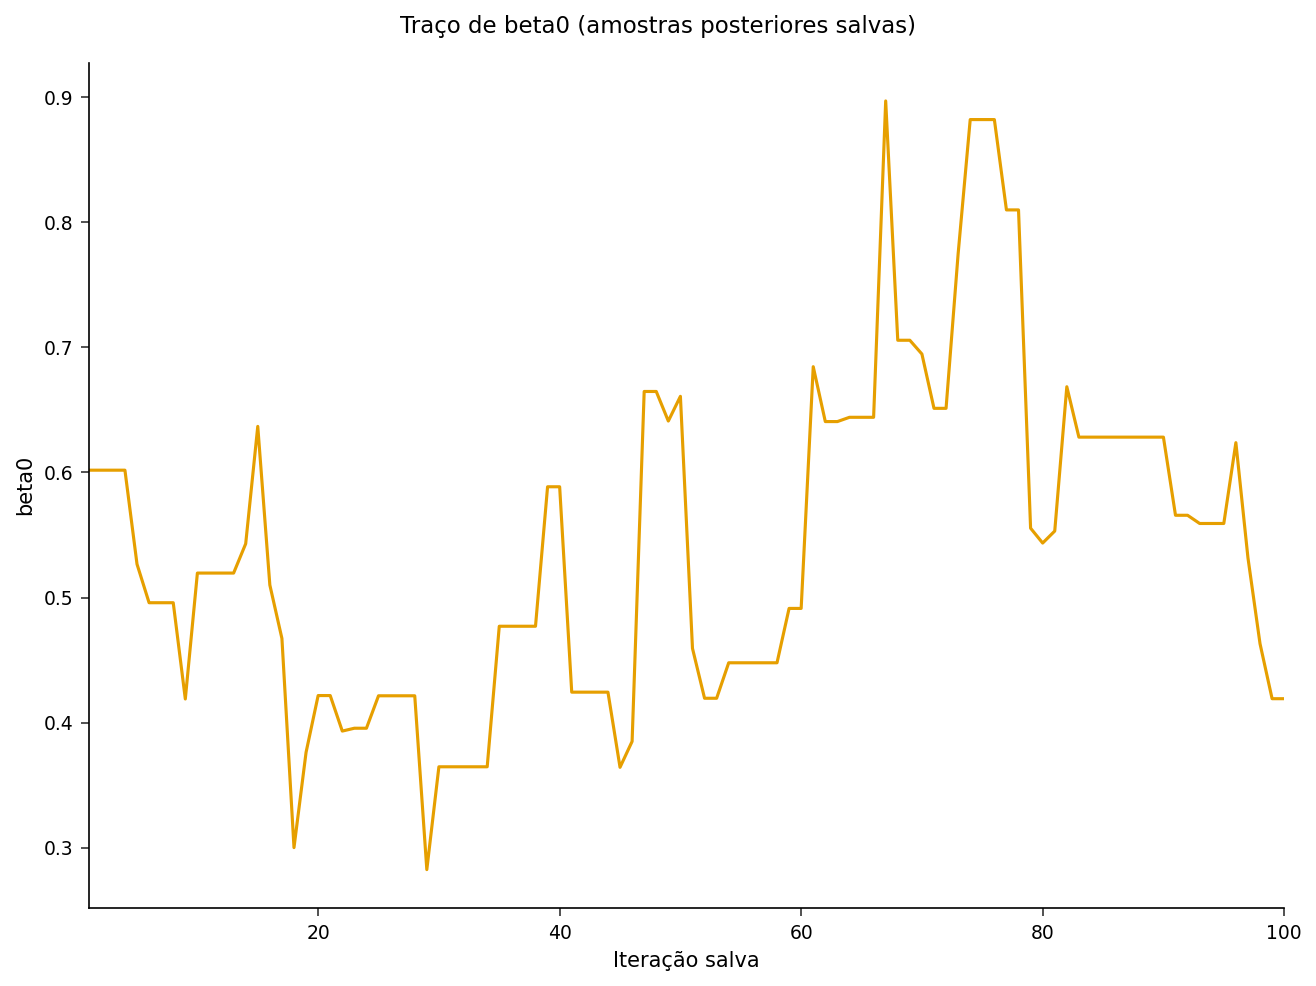

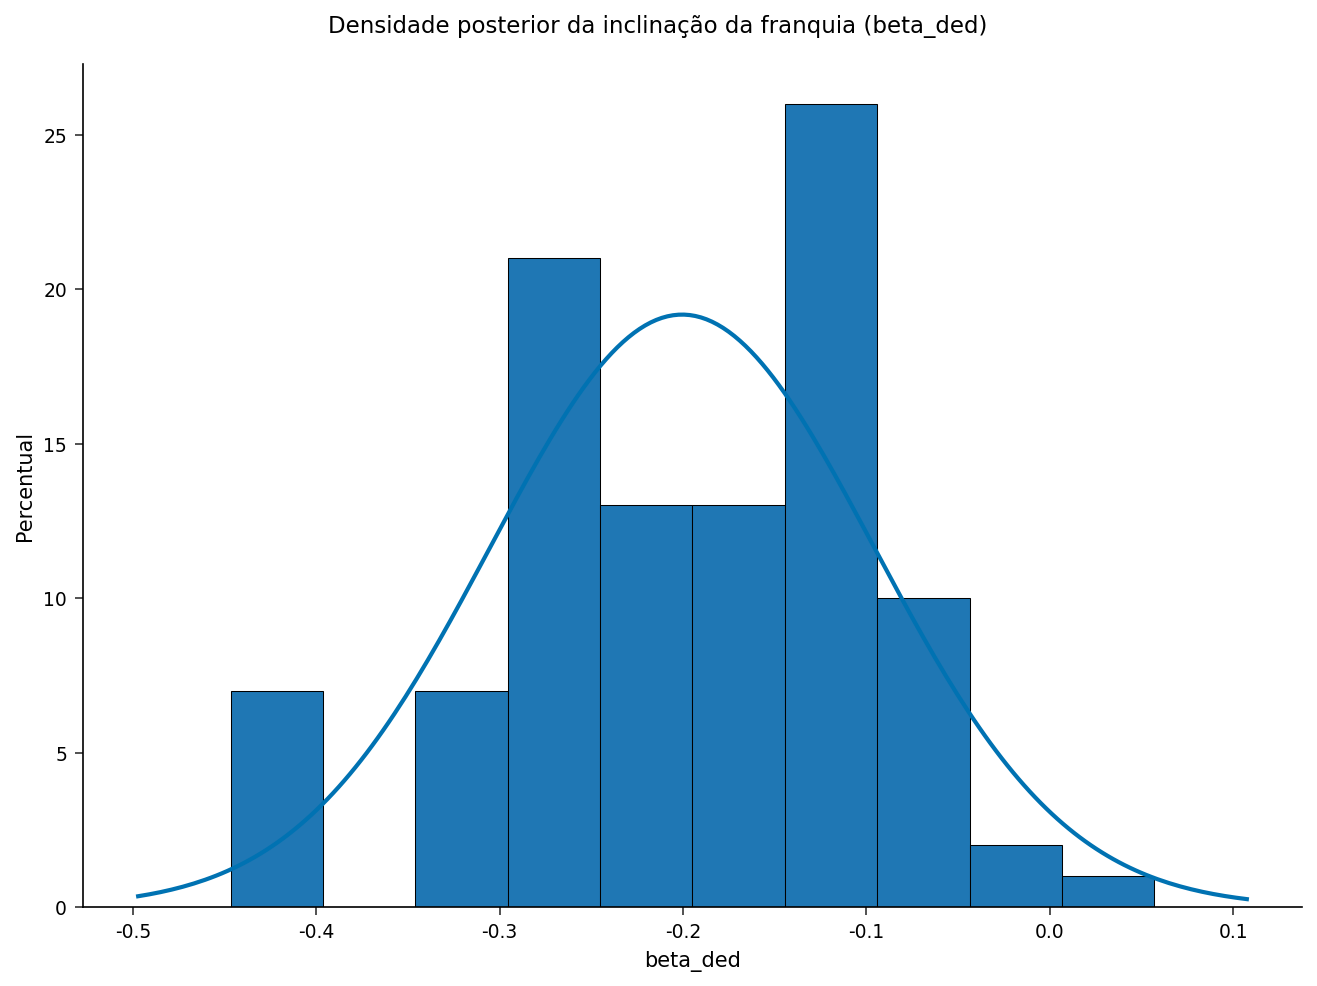

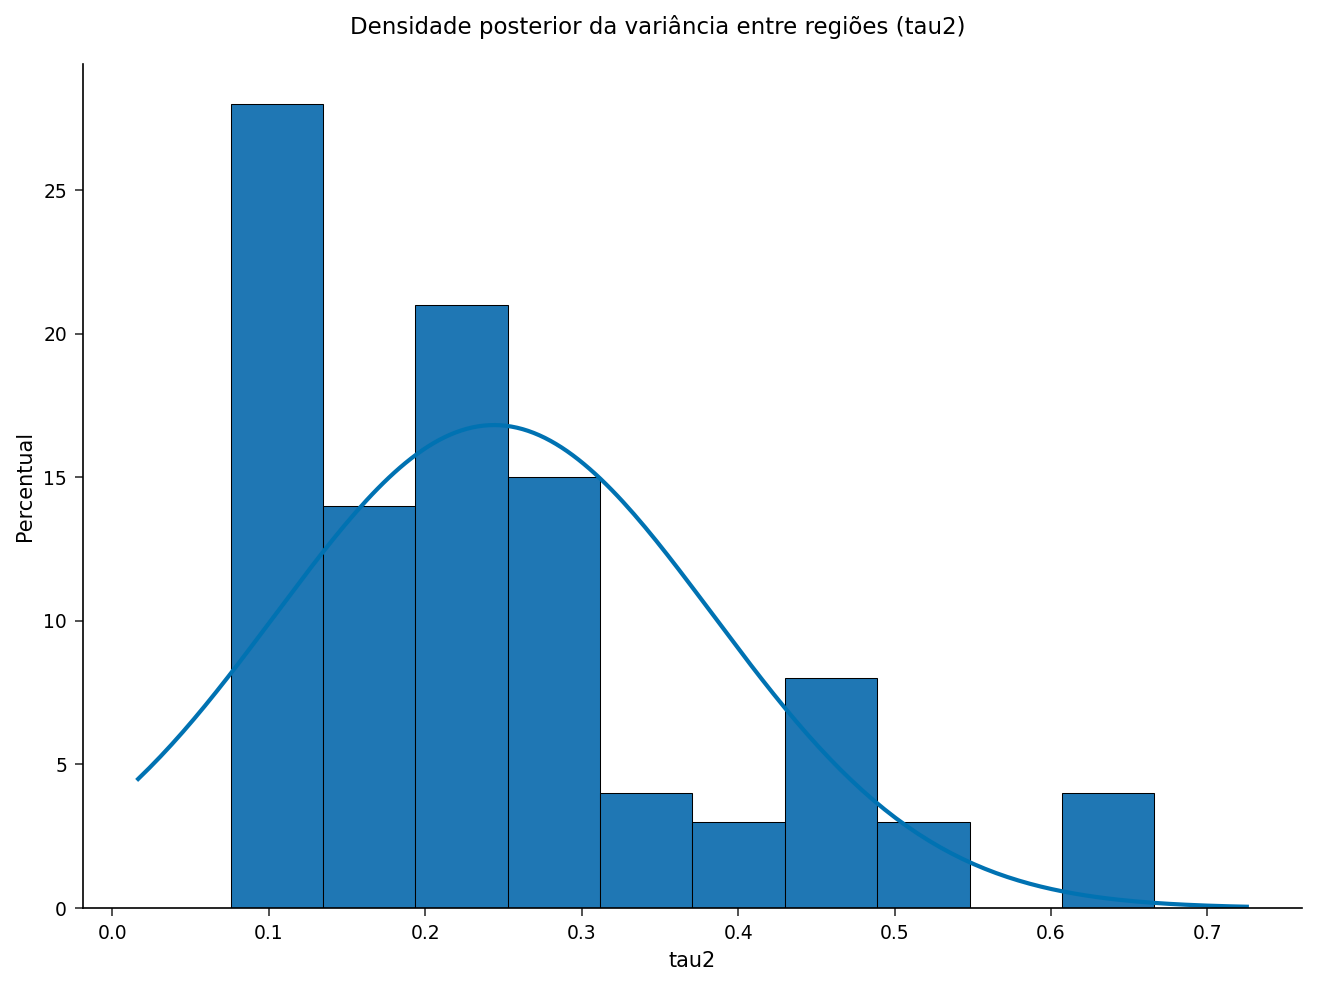

In [6]:
/* region_sd foi adicionado a post na visão de dados da Etapa 5 */
DADOS post2;
    DEFINIR post;
    region_sd = sqrt(tau2);
EXECUTAR;

/* Traço da log-frequência basal */
PROC SGPLOT DADOS=post2;
    SERIES x=iter y=beta0;
    TÍTULO 'Traço de beta0 (amostras posteriores salvas)';
    XAXIS RÓTULO='Iteração salva';
    YAXIS RÓTULO='beta0';
EXECUTAR;

/* Densidade posterior da inclinação da franquia */
PROC SGPLOT DADOS=post2;
    HISTOGRAM beta_ded;
    DENSITY   beta_ded;
    TÍTULO 'Densidade posterior da inclinação da franquia (beta_ded)';
    XAXIS RÓTULO='beta_ded';
    YAXIS RÓTULO='Percentual';
EXECUTAR;

/* Densidade posterior da variância entre regiões */
PROC SGPLOT DADOS=post2;
    HISTOGRAM tau2;
    DENSITY   tau2;
    TÍTULO 'Densidade posterior da variância entre regiões (tau2)';
    XAXIS RÓTULO='tau2';
    YAXIS RÓTULO='Percentual';
EXECUTAR;

## Interpretando os resultados

**O que o modelo entregou:**

- **Estrutura recuperada.** Os efeitos posteriores de região (`post_mean_u`) acompanham a verdade semeada (`true_eff`) em sinal e ordenação: a região 5 (verdade +0.40) é a mais alta, em +0.36, a região 4 (verdade -0.30) é a mais baixa, em -0.70, e a região 1 (verdade +0.05) fica perto do centro, em +0.20. A inclinação da franquia `beta_ded` fica em -0.13 (negativa, como o processo gerador de dados especificou, embora contraída em direção a zero pela pequena amostra de 96 apólices) e `beta0` recupera uma log-frequência basal de 0.43 — evidência de que a verossimilhança de Poisson hierárquica e o offset de exposição foram especificados corretamente.
- **Agrupamento parcial em ação.** Compare a `relativity` contraída da Etapa 4 com as frequências brutas da Etapa 2. A frequência bruta de 3.41 da região 5 é puxada para uma relatividade de 1.43, e a bruta de 0.45 da região 4 sobe para uma relatividade de 0.49 — as regiões pequenas são contidas em direção ao centro da carteira e carregam os **intervalos de credibilidade mais largos**, exatamente o comportamento que um atuário deseja: não sobretaxar nem subtaxar um território com base na força de alguns sinistros aleatórios.
- **Incerteza quantificada.** A posterior de `sqrt(tau2)` (média de cerca de 0.48) mede quanta heterogeneidade genuína entre regiões permanece depois de considerar a mistura de franquias e a exposição — uma entrada direta para a confiança na relatividade de território e para a incerteza de capital/reservas.
- **Diagnósticos e ajuste do modelo.** O **DIC relatado é 246.7**, uma régua para comparar esta especificação hierárquica com alternativas mais simples, totalmente agrupadas ou totalmente não agrupadas. Os tamanhos efetivos de amostra são modestos (`beta_ded` perto de 525, os efeitos aleatórios e `beta0` na casa das dezenas), e o **diagnóstico de Geweke sinaliza os três parâmetros monitorados** — o gráfico de traço mostra `beta0` deslizando para cima ao longo das primeiras 100 amostras salvas. Com apenas 96 apólices-ano e cadeias curtas no modo sem licença, essa não convergência é esperada; uma execução de produção alongaria o burn-in e a amostragem, e possivelmente reparametrizaria, antes de confiar nos intervalos.

**Por que Bayesiano aqui:** As relatividades de frequência alimentam diretamente a precificação, e os reguladores esperam cada vez mais a quantificação de incerteza. O PROC MCMC produz a *posterior inteira* para cada região, de modo que a seguradora pode afirmar, por exemplo, "a relatividade de frequência da região 4 tem um intervalo de credibilidade de 95% em torno de sua média posterior de 0.49" — uma afirmação que estimativas pontuais clássicas não podem fazer, e uma que é mais valiosa precisamente para os territórios pequenos e com poucos dados.